最新ファイル: change_point_pairs_pelt_rbf_20260418_102306.csv


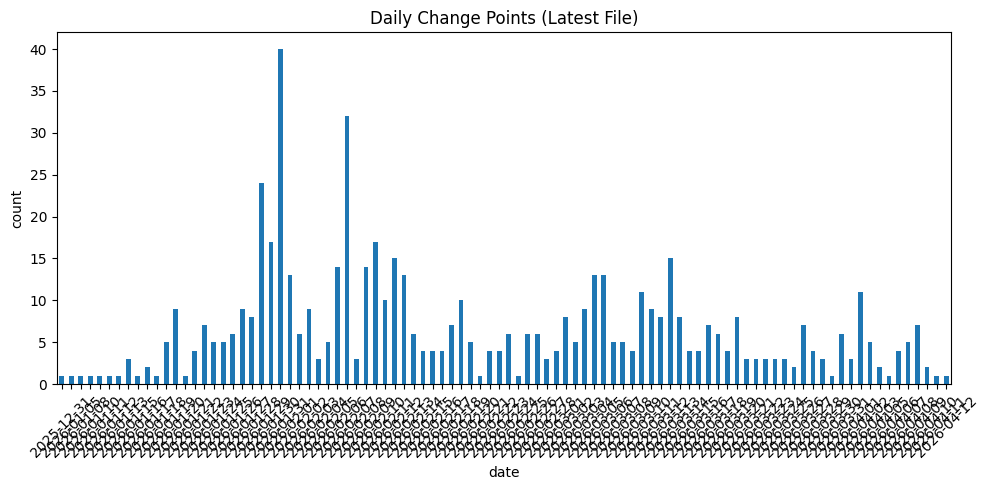

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================
# 0. カレントディレクトリから最新CSV取得（更新日時ベース）
# =========================================
current_dir = Path(".")

files = list(current_dir.glob("change_point_pairs_pelt_rbf_*.csv"))

if not files:
    raise FileNotFoundError("対象ファイルが見つかりません")

# ★ 更新日時で最新を取得
file_path = max(files, key=lambda f: f.stat().st_mtime)

print(f"最新ファイル: {file_path}")

# =========================================
# 1. CSV読み込み
# =========================================
df = pd.read_csv(
    file_path,
    skiprows=1,
    names=["coin", "datetime", "score"]
)

# =========================================
# 2. datetime変換
# =========================================
df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

df = df.dropna(subset=["datetime"])

# =========================================
# 3. 日付ごと集計
# =========================================
df["date"] = df["datetime"].dt.date

daily_counts = df.groupby("date").size().sort_index()

# =========================================
# 4. プロット
# =========================================
plt.figure(figsize=(10, 5))

daily_counts.plot(kind="bar")

plt.xlabel("date")
plt.ylabel("count")
plt.title("Daily Change Points (Latest File)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()